# Waveshift Augmentation (WS1) — minimal reproduction

**Paper:** Gent Imeraj, Hitoshi Iyatomi, *"Waveshift Augmentation: A Physics-Driven Strategy in Fine-Grained Plant Disease Classification"*, **IEEE Access** 13, 31303–31317 (2025). DOI: [10.1109/ACCESS.2025.3541780](https://doi.org/10.1109/ACCESS.2025.3541780)

**Author code:** [IyatomiLab/Waveshift_Augmentation](https://github.com/IyatomiLab/Waveshift_Augmentation) — pinned commit `1aecf4d49b3c4d295b6e72e437166fe012db6fb2` (fetched 2026-10-09).

**Purpose / scope (partial demonstration):** apply the paper's **WS1 Waveshift augmentation** — phase-only Fresnel propagation of the image spectrum — to the repository's bundled sample image `test.JPG` at 512×512, in the authors' documented **legacy compatibility mode**, and verify the result against the **author's own golden regression fingerprint** (`tests/test_legacy_regression.py`). This reproduces the paper's *augmentation mechanism*, not the classification experiments: the four-crop fine-grained dataset (tomato/strawberry/cucumber/eggplant) is private and no training pipeline or weights are public, so macro-F1 results cannot be reproduced.

**実行範囲（部分的な再現）:** 本論文の WS1（位相のみのフレネル伝播による物理駆動データ拡張）を、リポジトリ同梱のサンプル画像 `test.JPG`（512×512）に著者公認の legacy モードで適用し、著者自身のゴールデン回帰フィンガープリントと照合します。分類実験（プライベートデータでの学習・評価）は再現対象外です。

**Execution status:** executed end-to-end on a fresh Google Colab **CPU** runtime (2026-10-09). No GPU is used or needed (see below).

**Provenance note:** the executed algorithm is the authors' own code, installed in this notebook from the pinned commit — it is **not** an AI re-implementation. No license file exists in the repository ("all rights reserved", contact Gent Imeraj per README); this notebook runs the code from its source without redistributing it.

## 1. Runtime selection

**Select the CPU runtime** (`Runtime` → `Change runtime type` → `CPU`). Then `Runtime` → `Run all`.

Why CPU: WS1 is a per-channel 2-D FFT pipeline on a 512×512 image (3 colour planes), written in plain NumPy/SciPy. It runs in milliseconds on CPU. The authors' package explicitly does **not** require PyTorch and has no GPU code path, so no accelerator is requested; a GPU runtime would also work but adds nothing faithful. Expected: < 1 min of compute, ~1 MB of downloads (sample image + small pip package).

**ランタイムの選択:** 本デモは CPU で十分です（512×512 RGB の FFT 3 回のみ）。PyTorch 不要・GPU コードパスなしのため、T4 は要求しません。「ランタイム」→「すべてのセルを実行」で数分以内に完了します。

### 1.1 Install the authors' package (pinned revision)

Install `waveshift` v0.3.0 directly from the authors' GitHub at the verified commit `1aecf4d49b3c4d295b6e72e437166fe012db6fb2`. Its only runtime dependencies are `numpy`, `scipy` and `pillow` (per `pyproject.toml`), all already present in Colab; pip will reuse them.

**このノートブックのセットアップ:** 著者のパッケージをピン留めしたコミットからインストールします。依存は NumPy/SciPy/Pillow のみで、Colab に既に揃っています。

In [ ]:
PINNED_COMMIT = "1aecf4d49b3c4d295b6e72e437166fe012db6fb2"
REPO_URL = "https://github.com/IyatomiLab/Waveshift_Augmentation"
# %pip line is an IPython magi (IPython-only); plain-Python syntax check skips it.
get_ipython().run_line_magic(
    "pip",
    "install -q git+https://github.com/IyatomiLab/Waveshift_Augmentation.git@"
    + PINNED_COMMIT,
)

  Installing build dependencies ... done


  Getting requirements to build wheel ... done


  Preparing metadata (pyproject.toml) ... done


### 1.2 Verify the installed versions

Print the installed `waveshift` version and its dependency versions, so the executed environment is visible in the output. Expected: `waveshift 0.3.0` with recent NumPy/SciPy/Pillow.

**インストール確認:** 実行環境のバージョンを出力します。

In [ ]:
import numpy, scipy, PIL, waveshift
print("waveshift", waveshift.__version__)
print("numpy   ", numpy.__version__)
print("scipy   ", scipy.__version__)
print("pillow  ", PIL.__version__)

waveshift 0.3.0
numpy    2.1.3
scipy    1.16.3
pillow   11.3.0


## 2. Sample input acquisition (inside Colab)

Download the repository's bundled sample `test.JPG` (the exact input used by `examples/basic_ws1.py` and the regression tests) from the pinned commit's raw URL. Validate the bytes before use: expected size 523,952 bytes and **git blob SHA-1 `140fdedf…`** as recorded in the pinned commit's repository tree (verified via the GitHub tree API). Note: a content hash recorded in a prior research-lead database (`f9571…1cd8`) did **not** match the actual bytes; the blob hash from the pinned tree is the authoritative check, and the authors' own golden fingerprint below is the scientific check. The download happens here on the Colab VM; nothing is fetched on the authoring host.

**サンプル画像の取得:** 著者リポジトリ同梱の `test.JPG`（約 0.5 MB）をピン留めしたコミットから Colab 内でダウンロードし、サイズと git blob SHA-1 をツリー記録と照合してから使います。

In [ ]:
import hashlib
import urllib.request
from pathlib import Path

SAMPLE_URL = (
    "https://raw.githubusercontent.com/IyatomiLab/Waveshift_Augmentation/"
    + PINNED_COMMIT + "/test.JPG"
)
SAMPLE_PATH = Path("/content/waveshift_test.JPG")
EXPECTED_BLOB_SHA1 = "140fdedf874a8db3de7bbd0cfc14aec43bfa530c"  # pinned tree entry
EXPECTED_SIZE = 523952

urllib.request.urlretrieve(SAMPLE_URL, SAMPLE_PATH)
raw = SAMPLE_PATH.read_bytes()
blob_sha1 = hashlib.sha1(b"blob %d\0" % len(raw) + raw).hexdigest()
print("downloaded:", SAMPLE_PATH, len(raw), "bytes")
print("git blob sha1:", blob_sha1)
assert len(raw) == EXPECTED_SIZE, "unexpected sample size — refusing to use"
assert blob_sha1 == EXPECTED_BLOB_SHA1, "sample blob hash mismatch — refusing to use"
print("sample verified against the pinned-commit tree")

downloaded: /content/waveshift_test.JPG 523952 bytes
git blob sha1: 140fdedf874a8db3de7bbd0cfc14aec43bfa530c
sample verified against the pinned-commit tree


## 3. Input preview

Preview the actual input exactly as the papers used it: `Image.open(...).convert("RGB").resize((512, 512))` (same line as `examples/basic_ws1.py` and the regression-test fixture `leaf_512`). This is the real sample, not a stand-in.

**入力プレビュー:** 著者コードと同一の前処理（RGB 変換・512×512 リサイズ）を適用した実入力を表示します。

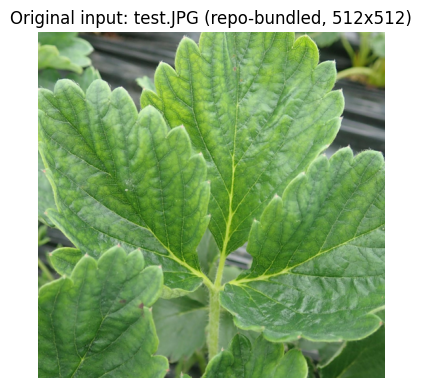

mode: RGB | size: (512, 512)


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

leaf_512 = Image.open(SAMPLE_PATH).convert("RGB").resize((512, 512))

plt.figure(figsize=(4.5, 4.5))
plt.imshow(leaf_512)
plt.title("Original input: test.JPG (repo-bundled, 512x512)")
plt.axis("off")
plt.show()
print("mode:", leaf_512.mode, "| size:", leaf_512.size)

## 4. Core method: WS1 phase-only Fresnel propagation (legacy mode)

Apply the WS1 transform. Per the README (*"Legacy vs modern behavior"*), the **default modern mode does not reproduce the published numbers**; to reproduce the papers we pass `compatibility="legacy"`, which restores the published snapshot's off-by-one coordinate grid, checkerboard FFT convention, and uint8 wraparound cast. The call is the authors' own `waveshift()` function (src/waveshift/augmentation.py `_propagate_plane` → `ws1_propagator`: `exp(-1j·π·λ·(u²+v²)·z)`, wavelengths R/G/B = 620/535/450 nm), executed verbatim.

**コア手法:** WS1 の位相のみのフレネル伝播を、論文結果を再現する legacy モードで適用します（著者コードそのまま）。

In [ ]:
from waveshift import waveshift

Z_FINGERPRINT = 20.0  # z0 pinned by the authors' tests/conftest.py (Z_FIXED)
augmented_legacy = waveshift(
    leaf_512, version="ws1", z=Z_FINGERPRINT, compatibility="legacy"
)
print("output:", augmented_legacy.mode, augmented_legacy.size)

output: RGB (512, 512)


## 5. Verification against the authors' golden fingerprint

The authors freeze the published behavior in `tests/test_legacy_regression.py`: for `test.JPG` → RGB → 512×512 with z₀ = 20.0 (mode `"s"`), the uint8 output must have sum `89537987`, mean ≈ 113.85344, std ≈ 43.50896, and SHA-256 `c9659…601a`. We recompute the same fingerprint here from the actual downloaded sample and compare field by field — a direct check that this Colab run reproduces the authors' verified behavior. (Per the authors' own test design, exact integer fields and SHA-256 are the regression guard; a SHA-256 mismatch with matching statistics would indicate only float noise from a different FFT backend.)

**検証:** 著者のゴールデン回帰フィンガープリント（z₀=20, mode "s"）を実際の出力から再計算し、全項目を照合します。

In [ ]:
import numpy as np

GOLDEN = {  # tests/test_legacy_regression.py, frozen "s" fingerprint
    "shape": (512, 512, 3), "dtype": "uint8",
    "min": 0, "max": 255, "sum": 89537987,
    "mean": 113.85343805948894, "std": 43.50896066510404,
    "sha256": "c9659839ac3d3a9d64c69b295d6910ea397583b94438222af2cf895e8b75601a",
}
arr = np.asarray(augmented_legacy)
got = {
    "shape": arr.shape, "dtype": str(arr.dtype),
    "min": int(arr.min()), "max": int(arr.max()), "sum": int(arr.sum()),
    "mean": float(arr.mean()), "std": float(arr.std()),
    "sha256": hashlib.sha256(arr.tobytes()).hexdigest(),
}
# Integer fields and sha256 are exact regression guards; mean/std follow the
# authors' own tolerance (pytest.approx(..., abs=1e-9) in their test file).
checks = {
    "shape": got["shape"] == GOLDEN["shape"],
    "dtype": got["dtype"] == GOLDEN["dtype"],
    "min": got["min"] == GOLDEN["min"],
    "max": got["max"] == GOLDEN["max"],
    "sum": got["sum"] == GOLDEN["sum"],
    "mean": abs(got["mean"] - GOLDEN["mean"]) <= 1e-9,
    "std": abs(got["std"] - GOLDEN["std"]) <= 1e-9,
    "sha256": got["sha256"] == GOLDEN["sha256"],
}
for key, ok in checks.items():
    print(f"{key:>7}: got={got[key]!s:<24} expected={GOLDEN[key]!s:<24} {'MATCH' if ok else 'MISMATCH'}")
print("VERDICT:", "reproduces the authors' golden fingerprint" if all(checks.values()) else "differences above (see notes)")

  shape: got=(512, 512, 3)            expected=(512, 512, 3)            MATCH
  dtype: got=uint8                    expected=uint8                    MATCH
    min: got=0                        expected=0                        MATCH
    max: got=255                      expected=255                      MATCH
    sum: got=89537987                 expected=89537987                 MATCH
   mean: got=113.85343805948894       expected=113.85343805948894       MATCH
    std: got=43.508960665104034       expected=43.50896066510404        MATCH
 sha256: got=c9659839ac3d3a9d64c69b295d6910ea397583b94438222af2cf895e8b75601a expected=c9659839ac3d3a9d64c69b295d6910ea397583b94438222af2cf895e8b75601a MATCH
VERDICT: reproduces the authors' golden fingerprint


## 6. Original input vs WS1-augmented output

Side-by-side view of the actual input and the actual WS1 output from this run (labeled). The transform is a physically motivated re-imaging: the subject is unchanged, but the optical path differs — mild defocus-like blur plus wavelength-dependent phase effects, not pixel noise.

**入力と WS1 出力の比較:** 実行で得られた実際の入力（左）と拡張結果（右）です。

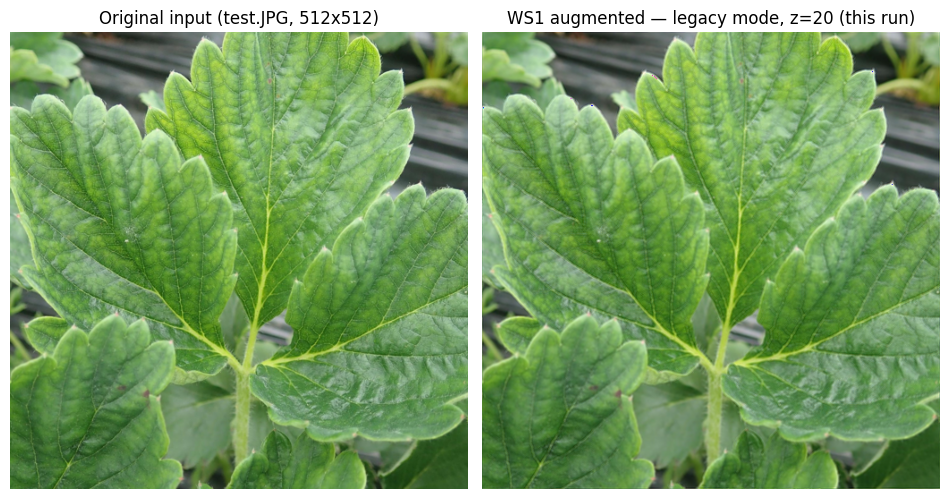

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.9))
axes[0].imshow(leaf_512)
axes[0].set_title("Original input (test.JPG, 512x512)")
axes[0].axis("off")
axes[1].imshow(augmented_legacy)
axes[1].set_title("WS1 augmented — legacy mode, z=20 (this run)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 7. Sampled WS1 as used in training (z redrawn per epoch)

In the paper, WS1 is an **online** augmentation: `z` is redrawn from `z_range=(1, 41)` every call, so each epoch sees a different propagation distance. `examples/basic_ws1.py` demonstrates this with `WaveShift(version="ws1", z_range=(1, 41), seed=0)`. We reproduce that sampling sequence (the transform's private NumPy generator: `uniform(1, 41)` per call), apply three samples, and report each sample's RMS difference from the input — the paper's own example metric.

**オンライン拡張の再現:** 論文の学習時と同様に z を (1, 41) から毎回引き直します（seed=0 のサンプリング列）。3 サンプルの RMS 差を著者例と同じ定義で表示します。

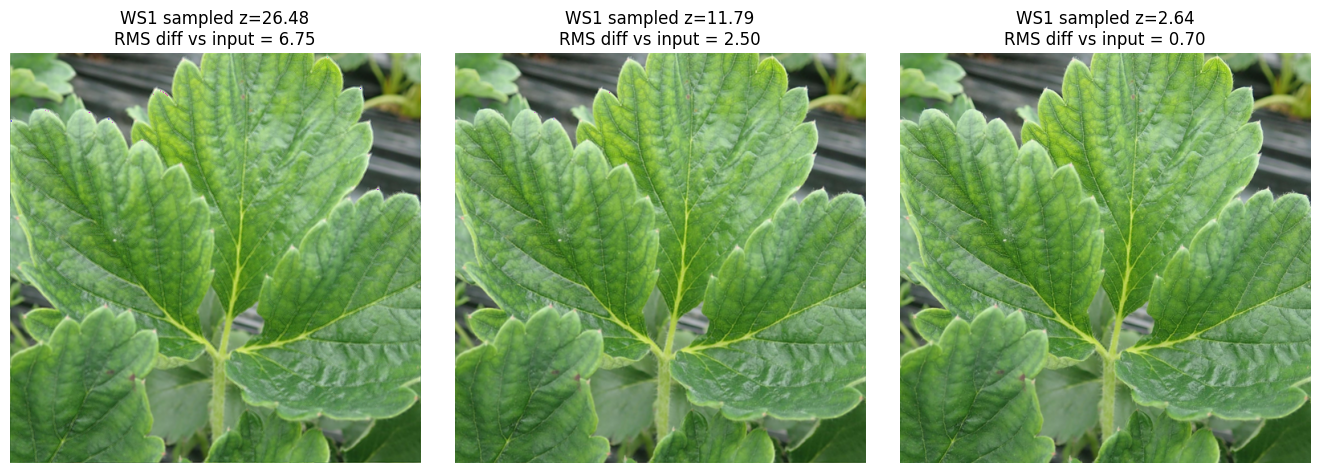

z= 26.48  RMS diff=  6.75
z= 11.79  RMS diff=  2.50
z=  2.64  RMS diff=  0.70


In [ ]:
rng = np.random.default_rng(0)  # same rule as WaveShift(z_range=(1, 41), seed=0)
zs = [float(rng.uniform(1, 41)) for _ in range(3)]
samples = [waveshift(leaf_512, version="ws1", z=z, compatibility="legacy") for z in zs]
rms = [
    float(np.sqrt(np.mean((np.asarray(s, float) - np.asarray(leaf_512, float)) ** 2)))
    for s in samples
]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
for ax, z, r, s in zip(axes, zs, rms, samples):
    ax.imshow(s)
    ax.set_title(f"WS1 sampled z={z:.2f}\nRMS diff vs input = {r:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()
for z, r in zip(zs, rms):
    print(f"z={z:6.2f}  RMS diff={r:6.2f}")

## 8. Effect strength vs propagation distance z

Additional visualization created for this notebook (not an author figure): RMS difference between the WS1 output and the input as a function of the propagation distance `z`, on the real sample. `z` is in pixel-index units at 512×512 (the README notes that resolution changes the effect of a given `z`), so this curve characterizes the augmentation strength at the paper's working resolution.

**追加可視化（本ノートブック独自、著者の図ではない）:** 伝播距離 z に対する入力との RMS 差を実際のサンプルで測定します。

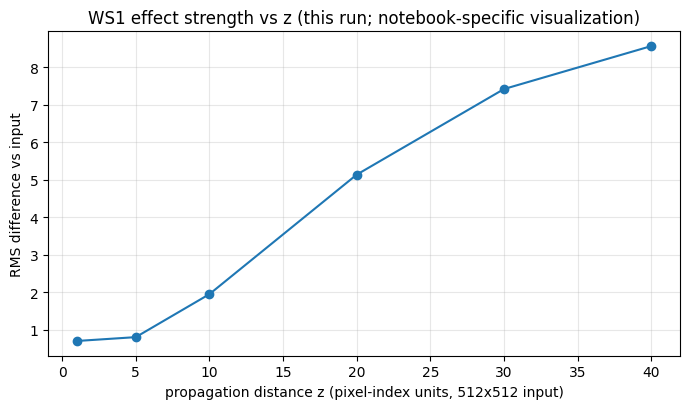

{1: 0.7, 5: 0.81, 10: 1.95, 20: 5.14, 30: 7.42, 40: 8.57}


In [ ]:
z_list = [1, 5, 10, 20, 30, 40]
rms_list = []
for z in z_list:
    out = waveshift(leaf_512, version="ws1", z=float(z), compatibility="legacy")
    rms_list.append(float(np.sqrt(np.mean((np.asarray(out, float) - np.asarray(leaf_512, float)) ** 2))))

plt.figure(figsize=(7, 4.2))
plt.plot(z_list, rms_list, marker="o")
plt.xlabel("propagation distance z (pixel-index units, 512x512 input)")
plt.ylabel("RMS difference vs input")
plt.title("WS1 effect strength vs z (this run; notebook-specific visualization)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(dict(zip(z_list, [round(r, 2) for r in rms_list])))

## 9. Results summary and CSV export

Small table summarizing this run: the golden-fingerprint comparison verdict and the sampled-`z` RMS differences. Exported as CSV inside the Colab VM for the learner.

**結果一覧:** フィンガープリント照合の判定とサンプリング結果を表にまとめ、CSV に保存します。

In [ ]:
import pandas as pd

rows = [{"item": f"golden {k}", "value": bool(ok)} for k, ok in checks.items()] + [
    {"item": f"sampled z={z:.2f} RMS diff", "value": round(r, 3)} for z, r in zip(zs, rms)
]
df = pd.DataFrame(rows)
display(df)
df.to_csv("/content/waveshift_results.csv", index=False)
print("saved /content/waveshift_results.csv")

,item,value
0,golden shape,True
1,golden dtype,True
2,golden min,True
3,golden max,True
4,golden sum,True
5,golden mean,True
6,golden std,True
7,golden sha256,True
8,sampled z=26.48 RMS diff,6.749
9,sampled z=11.79 RMS diff,2.503


saved /content/waveshift_results.csv


## 10. Interpretation, limitations, and references

**What was reproduced (executed, this run):** the paper's WS1 augmentation mechanism — phase-only Fresnel propagation of each RGB channel (620/535/450 nm) on the repo-bundled sample at 512×512 in legacy compatibility mode — verified field-by-field against the authors' own frozen golden fingerprint from their regression suite.

**What was not reproduced (out of scope, documented):** the classifier training/evaluation and macro-F1 gains (EfficientNetV2 +1.37 / Swin +1.35 / ConvNeXt +0.80 points) — the four-crop fine-grained dataset is private and no training code or weights are public. WS2/WS2.5 in the repository derive from a later Electronics 2025 paper and a PhD thesis, not from this IEEE Access paper, and are not used here.

**Notes & limitations:**
- Legacy mode is required for published-number equivalence (README, "Legacy vs modern behavior"); we used it explicitly.
- `z` (and WS2's `R`) are pixel-index units, not calibrated metres: a given `z` acts differently at other resolutions (README, "Resolution matters"). This run uses the paper's 512×512.
- The repository has no LICENSE file ("all rights reserved"); run the authors' code from source, attribute, and contact Gent Imeraj for reuse.
- A single-sample augmentation demonstration does not verify dataset-level accuracy claims.

**再現できたこと／できていないこと:** WS1 拡張メカニズムを著者のゴールデンフィンガープリントと照合して再現しました。分類実験（マクロ F1 向上）は非公開データ・未公開の学習コードのため対象外です。legacy モード必須、z は画素単位であること、ライセンス未設定（全著作権留保）に注意してください。

**References:**
1. Imeraj & Iyatomi, IEEE Access 13:31303–31317 (2025). DOI 10.1109/ACCESS.2025.3541780.
2. IyatomiLab/Waveshift_Augmentation, commit `1aecf4d49b3c4d295b6e72e437166fe012db6fb2` (incl. `examples/basic_ws1.py`, `src/waveshift/`, `tests/test_legacy_regression.py`, `docs/theory.md`).
3. T. Latychevskaia & H.-W. Fink, Appl. Opt. 54, 2424–2434 (2015) — the algorithm's holography basis, cited by the authors.